In [13]:

import numpy as np
%matplotlib inline
import pandas as pd
import seaborn as sns
from sklearn.svm import SVC
from joblib import dump, load
import matplotlib.pyplot as plt
from sklearn.svm import LinearSVC
from sklearn.metrics import RocCurveDisplay
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import train_test_split
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.metrics import precision_score, recall_score, f1_score

In [14]:
# Read data and save it to a DataFrame
heart_disease = pd.read_csv("heart-disease.csv")

# Check the first 5 rows of the data
heart_disease.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


In [15]:
# Check info about the data
heart_disease.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        303 non-null    int64  
 12  thal      303 non-null    int64  
 13  target    303 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 33.3 KB


In [16]:
# Features
X = heart_disease.drop("target", axis=1)

# Target value
y = heart_disease['target']

In [17]:
# Split training and testing 
X_train, X_test, y_train, y_test = train_test_split(X, y)

In [18]:
# Check the shape 
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((227, 13), (76, 13), (227,), (76,))

### Preparing the ML model

In [19]:
# Instantiate the model
clf = RandomForestClassifier()

### Fitting the model

In [20]:
# Fit the data to the model
clf.fit(X_train, y_train)

RandomForestClassifier()

In [21]:
# Save the predictions of the testing data
y_preds = clf.predict(X_test)

### Evaluating predictions

In [22]:
# Score of tranining set
clf.score(X_train, y_train)

1.0

In [23]:
# Score of testing set
clf.score(X_test, y_test)

0.7894736842105263

### Experimenting different classification models

In [24]:
models = {"LinearSVC": LinearSVC(),
          "KNN": KNeighborsClassifier(),
          "SVC": SVC(),
          "LogisticRegression": LogisticRegression(),
          "RandomForestClassifier": RandomForestClassifier()
          }

# A dictionary to store the results
results = {}

In [25]:
np.random.seed(42)

for model_name, model in models.items():
    model.fit(X_train, y_train)
    results[model_name] = model.score(X_test, y_test)

# View the results
results

/Users/layalsaadeddine/Desktop/AI engineers/aienv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


{'LinearSVC': 0.7368421052631579,
 'KNN': 0.7105263157894737,
 'SVC': 0.618421052631579,
 'LogisticRegression': 0.7236842105263158,
 'RandomForestClassifier': 0.7763157894736842}

<Axes: >

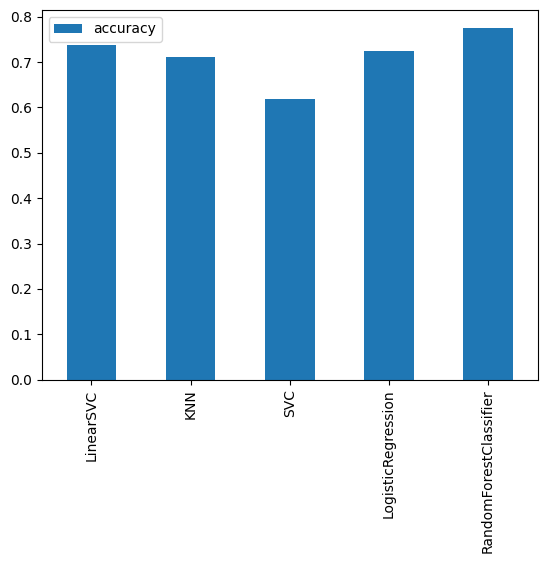

In [26]:
results_df = pd.DataFrame(results.values(), 
                          results.keys(), 
                          columns=['accuracy'])

# Create a bar plot of the results dataframe using plot.bar()
results_df.plot.bar()

In [27]:
results_df

,accuracy
LinearSVC,0.736842
KNN,0.710526
SVC,0.618421
LogisticRegression,0.723684
RandomForestClassifier,0.776316


### Hyperparameter Tuning

In [28]:
# Different LogisticRegression hyperparameters
log_reg_grid = {"C": np.logspace(-4, 4, 20),
                "solver": ["liblinear"]}

In [29]:
np.random.seed(42)

# RandomizedSearchCV with a LogisticRegression() estimator,
rs_log_reg = RandomizedSearchCV(estimator=LogisticRegression(),
                                param_distributions=log_reg_grid,
                                cv=5,
                                n_iter=5,
                                verbose=1)

# Fitting the instance of RandomizedSearchCV
rs_log_reg.fit(X_train, y_train)

Fitting 5 folds for each of 5 candidates, totalling 25 fits


RandomizedSearchCV(cv=5, estimator=LogisticRegression(), n_iter=5,
                   param_distributions={'C': array([1.00000000e-04, 2.63665090e-04, 6.95192796e-04, 1.83298071e-03,
       4.83293024e-03, 1.27427499e-02, 3.35981829e-02, 8.85866790e-02,
       2.33572147e-01, 6.15848211e-01, 1.62377674e+00, 4.28133240e+00,
       1.12883789e+01, 2.97635144e+01, 7.84759970e+01, 2.06913808e+02,
       5.45559478e+02, 1.43844989e+03, 3.79269019e+03, 1.00000000e+04]),
                                        'solver': ['liblinear']},
                   verbose=1)

In [30]:
# Check the best parameters
rs_log_reg.best_params_

{'solver': 'liblinear', 'C': np.float64(0.23357214690901212)}

In [31]:
# Check the best score
rs_log_reg.best_score_

np.float64(0.8726570048309178)

### Model Evaluation

In [32]:
# Instantiate a LogisticRegression classifier using the best hyperparameters from RandomizedSearchCV
clf = LogisticRegression(**rs_log_reg.best_params_)

# Fitting the new instance with the best hyperparameters on the training data 
clf.fit(X_train, y_train)

LogisticRegression(C=np.float64(0.23357214690901212), solver='liblinear')

In [33]:
# make predictions on test 
y_pred = clf.predict(X_test)

In [34]:
# Confusion matrix
confusion_matrix(y_test, y_pred)

array([[28, 11],
       [10, 27]])

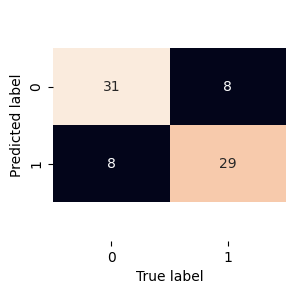

In [35]:
def plot_conf_mat(y_test, y_preds):
    fig, ax = plt.subplots(figsize=(3, 3))
    ax = sns.heatmap(confusion_matrix(y_test, y_preds),
                     annot=True, # Annotate the boxes
                     cbar=False)
    plt.xlabel("True label")
    plt.ylabel("Predicted label")
    
    # Fix the broken annotations (this happened in Matplotlib 3.1.1)
    bottom, top = ax.get_ylim()
    ax.set_ylim(bottom + 0.5, top - 0.5);
    
plot_conf_mat(y_test, y_preds)

In [36]:
# Create a classification report 
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.74      0.72      0.73        39
           1       0.71      0.73      0.72        37

    accuracy                           0.72        76
   macro avg       0.72      0.72      0.72        76
weighted avg       0.72      0.72      0.72        76



In [37]:
# Precision
precision_score(y_test, y_pred)

0.7105263157894737

In [38]:
# Recall
recall_score(y_test, y_pred)

0.7297297297297297

In [39]:
# f1 score
f1_score(y_test, y_pred)

0.72

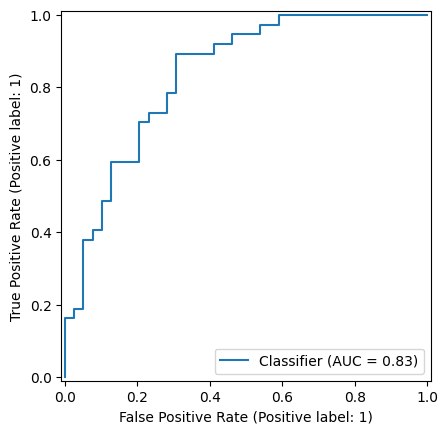

In [40]:
# Plotting the ROC curve
y_score = clf.predict_proba(X_test)[:, 1]
RocCurveDisplay.from_predictions(y_test, y_score)

In [41]:
# Checking the cross validation scores
cross_val_score(clf, 
                X, 
                y, 
                scoring="accuracy",
                cv=5)

array([0.81967213, 0.90163934, 0.8852459 , 0.88333333, 0.75      ])

In [42]:
# Cross validation precision
cross_val_score(clf, 
                X, 
                y, 
                scoring="precision",
                cv=5)

array([0.775     , 0.88571429, 0.86111111, 0.86111111, 0.725     ])

In [43]:
# Cross validation recall
cross_val_score(clf, 
                X, 
                y, 
                scoring="recall",
                cv=5)

array([0.93939394, 0.93939394, 0.93939394, 0.93939394, 0.87878788])

In [44]:
# Cross validation f1 score
cross_val_score(clf, 
                X, 
                y, 
                scoring="f1",
                cv=5)

array([0.84931507, 0.91176471, 0.89855072, 0.89855072, 0.79452055])

### Exporting the model

In [45]:
# Use the dump function to export the trained model to file
dump(clf,"clf_model.joblib")

['clf_model.joblib']

In [46]:
loaded_model = load("clf_model.joblib")

# Evaluate the loaded trained model on the test data
print(f'Model score: {clf.score(X_test, y_test)}')
print(f'Loaded model score: {loaded_model.score(X_test, y_test)}')

Model score: 0.7236842105263158
Loaded model score: 0.7236842105263158
